In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# OOD performance

In [4]:
df_base_path = '../results'

In [17]:
# Load your three dataframes
baseline_df = pd.read_csv(f"{df_base_path}/baseline_by_celltype_correlations.csv")
cellina_df = pd.read_csv(f"{df_base_path}/cellina_by_celltype_correlations.csv")
cpa_df = pd.read_csv(f"{df_base_path}/cpa_by_celltype_correlations.csv")

# remove epithelial row from cpa
cpa_df = cpa_df[cpa_df['celltype'] != 'Epithelial']

# Add a column to identify the source dataframe
baseline_df['method'] = 'baseline'
cpa_df['method'] = 'cpa'
cellina_df['method'] = 'cellina'

# Combine them
df_all = pd.concat([baseline_df, cpa_df, cellina_df], ignore_index=True)

# Melt the dataframe so we can plot pearson and spearman separately
df_melt = df_all.melt(id_vars=['celltype', 'method'], value_vars=['pearson', 'spearman'],
                      var_name='correlation', value_name='value')

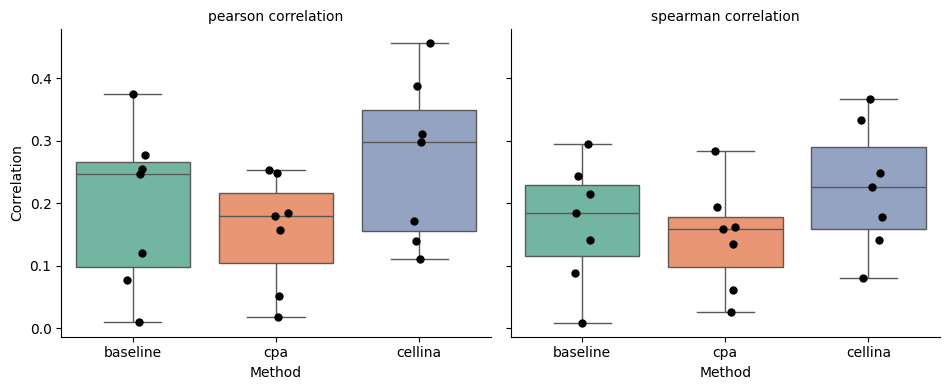

In [18]:
g = sns.catplot(
    data=df_melt, kind="box",
    x="method", y="value", hue="method",
    col="correlation",  # separate plots for pearson and spearman
    dodge=False, palette="Set2",
    height=4, aspect=1.2
)

# Add the individual points (dots) for each cell type
for ax, corr_type in zip(g.axes[0], ['pearson', 'spearman']):
    sns.stripplot(
        data=df_melt[df_melt['correlation']==corr_type],
        x='method', y='value', color='black', size=6, ax=ax, jitter=True
    )

g.set_axis_labels("Method", "Correlation")
g.set_titles("{col_name} correlation")
plt.show()

# LFC agreement between observed and reconstructed counts

In [19]:
cellina_de = pd.read_csv(f"{df_base_path}/cellina_de.csv", index_col=0).T
cpa_de = pd.read_csv(f"{df_base_path}/cpa_de.csv", index_col=0).T

In [20]:
cpa_de.index.name = "celltype"
cellina_de.index.name = "celltype"

/tmp/ipykernel_2026619/1853090153.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,


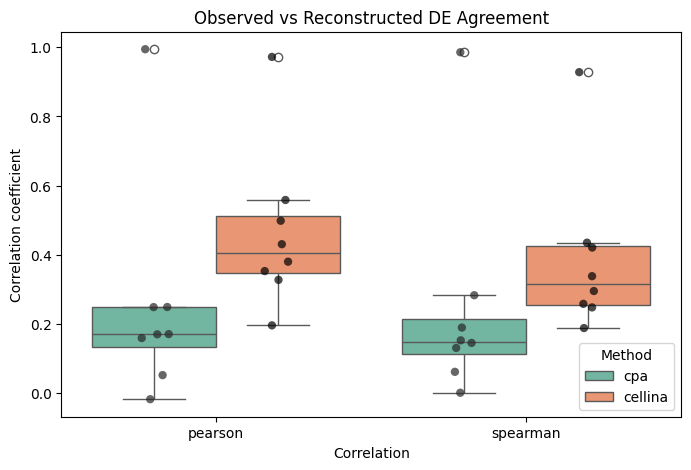

In [21]:
# Add a column to identify the source dataframe
cpa_de['method'] = 'cpa'
cellina_de['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_de, cellina_de])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Correlation", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Correlation", y="Value", hue="method", data=df_melted, palette="Set2")
sns.stripplot(x="Correlation", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Observed vs Reconstructed DE Agreement")
plt.ylabel("Correlation coefficient")
plt.show()

# E-distances between observed and reconstructed cells

In [22]:
cellina_edist = pd.read_csv(f"{df_base_path}/cellina_edist.csv", index_col=0)
cpa_edist = pd.read_csv(f"{df_base_path}/cpa_edist.csv", index_col=0)

In [23]:
cpa_edist.index.name = "celltype"
cellina_edist.index.name = "celltype"

/tmp/ipykernel_2026619/1993656564.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,


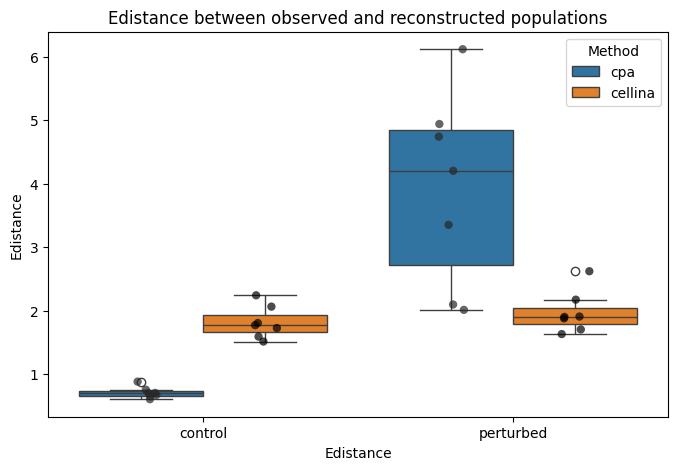

In [24]:
# Add a column to identify the source dataframe
cpa_edist['method'] = 'cpa'
cellina_edist['method'] = 'cellina'

# Combine both DataFrames
df_all = pd.concat([cpa_edist, cellina_edist])

# Melt for seaborn: long-form
df_melted = df_all.reset_index().melt(id_vars=["celltype", "method"], var_name="Edistance", value_name="Value")

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="Edistance", y="Value", hue="method", data=df_melted, palette="tab10")
sns.stripplot(x="Edistance", y="Value", hue="method", data=df_melted,
              dodge=True, color="black", size=6, jitter=True, alpha=0.7)

# Remove duplicate legend entries from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")

plt.title("Edistance between observed and reconstructed populations")
plt.ylabel("Edistance")
plt.show()

# LOO plots

In [110]:
import os
import glob
import json

corr_dir = "/data2/a330d/datasets/crc/correlations"
pattern = os.path.join(corr_dir, "crc_*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    if not name.startswith("crc_") or not name.endswith(".json"):
        continue
    core = name[len("crc_"):-len(".json")]
    parts = core.split("_")
    if len(parts) < 3:
        # unexpected filename, skip
        continue
    sid = parts[0]
    model_name = parts[1]
    
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision@50"),
            "edistance_cells": data.get("edistance_cells"),
            "edistance_latents": data.get("edistance_latents"),
            "edistance_local": data.get("edistance_local"),
            "mixing_index": data.get("mixing_index")
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

columns = ["sid", "model_name", "holdout_celltype", "spearman", "pearson", "precision", "edistance_cells", "edistance_latents", "edistance_local", "mixing_index"]
crc_corr_df = pd.DataFrame(rows, columns=columns)

In [111]:
keep_rows = ['cf']
# Match substring from above and keep those rows
crc_corr_df = crc_corr_df[crc_corr_df['model_name'].str.contains('|'.join(keep_rows))]
# Remove rows which contain 'recon' substring
crc_corr_df = crc_corr_df[~crc_corr_df['model_name'].str.contains('recon')]

In [112]:
crc_corr_df = crc_corr_df[crc_corr_df['holdout_celltype'] != 'B_cell'] # Reason: Missing in two slides

# Remove baseline, cellina-ablated, cellina-graph
#exclude_models = ['cellina-ablated', 'cellina-graph', 'cellina-cf-recon']
#crc_corr_df = crc_corr_df[~crc_corr_df['model_name'].isin(exclude_models)]

In [113]:
# Load mintflow results
df = crc_corr_df.copy() # start with existing dataframe
mintflow_base_path = "/data/a330d/projects/cellina-reproducibility-worktrees/cellina-reproducibility-mintflow/results/mintflow_crc"
mintflow_model_name = "mintflow-normalized"
load_sids_mintflow = ['231', '210', '242', '232', '221']
for i in load_sids_mintflow:
    mintflow_df = pd.read_csv(f"{mintflow_base_path}/{mintflow_model_name}_{i}_by_celltype_correlations.csv")
    df = pd.concat([df, mintflow_df], ignore_index=True)

In [114]:
# Remove rows of sid 110, 231 and rows of model_name 'cellina-graph' and 'cellina-ablated'
discard_slides = ['110', '222']# 110 has very low correlations for all models, 222 does not have CRC
df = df[~df['sid'].isin(discard_slides)]

In [115]:
model_rename = {
    #"cellina": "cellina",
    #"cellina-cf-recon": "cellina-recon",
    "cellina-cf": "cellina",
    "cpa-cf": "cpa",
    "baseline-cf": "baseline",
    "scgen-cf": "scgen",
    "cellina-ablated-cf": "cellina-ablated",
    "cellina-mmd-cf": "cellina-mmd",
    mintflow_model_name: "mintflow"
}

# Rename
df.loc[:, "model_name"] = df["model_name"].map(model_rename)

In [116]:
metrics = ["pearson", "spearman", "precision", "mixing_index"]
#metrics = ["edistance_cells", "edistance_local"]
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "mintflow",
    "cellina-ablated",
    "cellina-mmd",
    "cpa",
    "scgen",
    "cellina",
]

palette = 'colorblind'

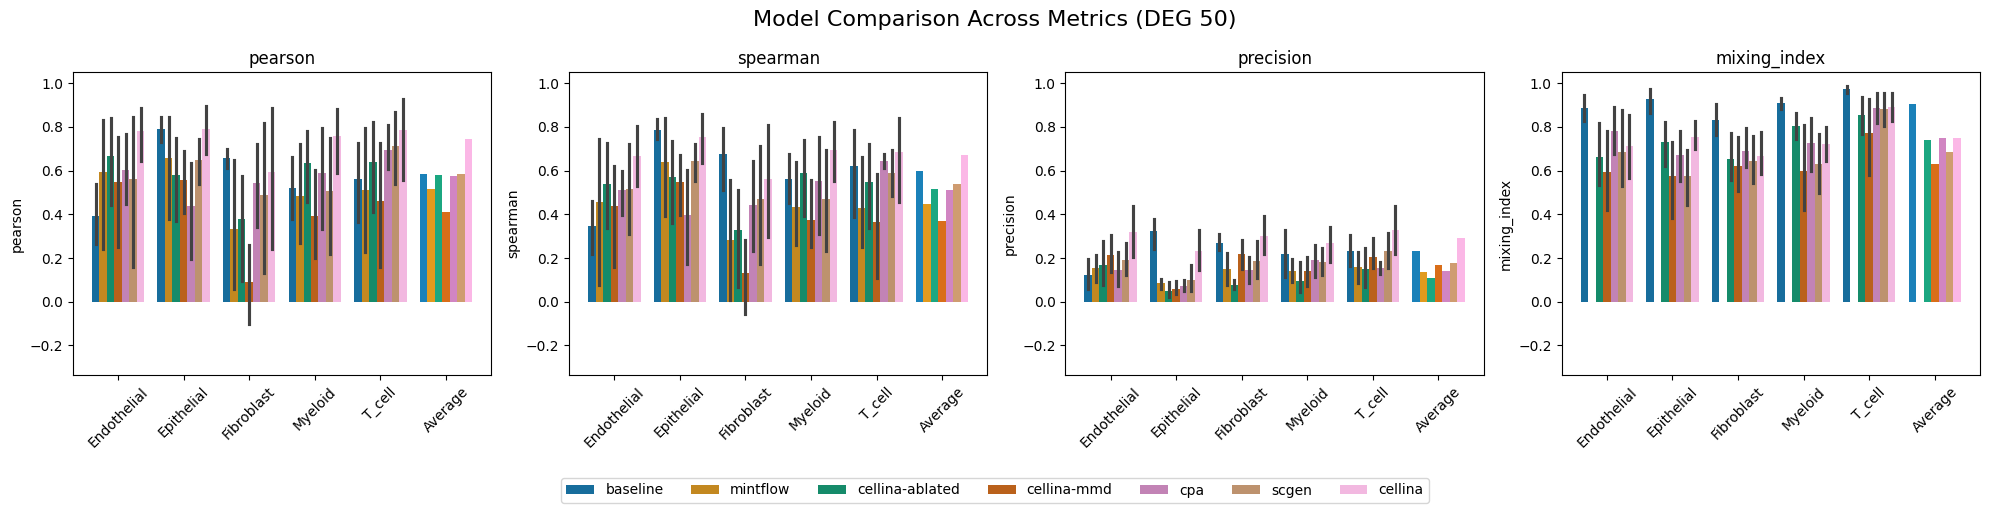

In [117]:
# Compute global y-limits
ymin = df[metrics].min().min() * 0.95
ymax = df[metrics].max().max() * 1.05

fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 5))
fig.suptitle("Model Comparison Across Metrics (DEG 50)", fontsize=16)

for ax, metric in zip(axes, metrics):

    # Original cell types
    celltypes = df[grouping].unique().tolist()
    # Add "Average" at the end
    all_x_labels = list(celltypes) + ["Average"]

    # ---- Barplot per celltype ----
    sns.barplot(
        data=df,
        x=grouping,
        y=metric,
        hue="model_name",
        estimator="mean",
        errorbar=("ci", 95),
        hue_order=model_order,
        ax=ax,
        palette=palette,
        order=celltypes,
    )
    ax.legend_.remove()

    # ---- Add model-wise average across celltypes ----
    df_avg = df.groupby("model_name")[metric].mean().reset_index()
    n_models = len(model_order)
    bar_width = 0.8 / n_models  # same as seaborn default for hue spacing

    for i, model in enumerate(model_order):
        avg_val = df_avg.loc[df_avg.model_name == model, metric].values[0]
        # x-position: last group ("Average") + offset for model
        x_pos = len(celltypes) - 0.4 + i * bar_width + bar_width/2
        ax.bar(
            x=x_pos,
            height=avg_val,
            width=bar_width,
            color=sns.color_palette(palette)[i],
            alpha=0.9,
        )

    # ---- Set x-ticks ----
    ax.set_xticks(range(len(all_x_labels)))
    ax.set_xticklabels(all_x_labels, rotation=45)

    # Set y-limits
    ax.set_ylim(ymin, ymax)
    ax.set_title(metric)
    ax.set_xlabel("")

# ---- Global Legend ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), fontsize=10,
           loc="lower center", bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()